# Phase 7 — Exploratory Data Analysis (EDA)

## Project: Reducing Customer Churn at Meridian Retail Group

### Introduction

This phase focuses on exploratory data analysis to understand customer behaviour and identify factors associated with customer churn at Meridian Retail Group. The analysis uses the five cleaned datasets produced during Phase 6: customers, products, orders, order items, and support tickets.

Customer churn is defined using a 180-day inactivity period. A customer is classified as churned when more than 180 days have passed since their most recent completed order. This definition provides a consistent and measurable basis for analysing customer retention.

### Objectives

This notebook performs exploratory data analysis to:

* Define and calculate customer churn using the 180-day inactivity rule.
* Calculate and interpret the overall customer churn rate.
* Analyse churn across important customer segments, including membership tier, preferred channel, state, referral source, and signup cohort.
* Engineer RFM-style customer features:

  * **Recency** — number of days since the customer's most recent completed order.
  * **Frequency** — number of completed orders.
  * **Monetary** — total and average spending from completed orders.
* Investigate the relationship between support-ticket activity, customer satisfaction, resolution time, and churn.
* Perform univariate analysis to understand the distribution of important customer and behavioural variables.
* Perform multivariate analysis to investigate relationships among churn, RFM characteristics, and support-ticket activity.
* Identify at least five concrete and actionable business insights that can help Meridian Retail Group understand and reduce customer churn.

### Expected Outcome

The analysis will produce a customer-level dataset combining customer characteristics, churn status, RFM features, and support-ticket measures. These results will provide the analytical foundation for the visualizations developed in Phase 8 and the churn prediction model developed in Phase 9.


In [57]:
# =========================================================
# CELL 2 — IMPORT LIBRARIES
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

print("Libraries imported successfully.")

Libraries imported successfully.


In [58]:
# =========================================================
# CELL 3 — MOUNT GOOGLE DRIVE
# =========================================================

from google.colab import drive

drive.mount("/content/drive")

print("Google Drive mounted successfully.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted successfully.


In [59]:
# =========================================================
# CELL 4 — DEFINE PROJECT PATHS
# =========================================================

from pathlib import Path

PROJECT_PATH = Path(
    "/content/drive/MyDrive/Meridian Retail Group - Customer Churn Capstone "
)

DATA_PATH = PROJECT_PATH / "Data"

CLEANED_PATH = DATA_PATH / "Cleaned Data"

print("Project path:")
print(PROJECT_PATH)

print("\nCleaned Data path:")
print(CLEANED_PATH)

print("\nProject folder exists:", PROJECT_PATH.exists())
print("Cleaned Data folder exists:", CLEANED_PATH.exists())

Project path:
/content/drive/MyDrive/Meridian Retail Group - Customer Churn Capstone 

Cleaned Data path:
/content/drive/MyDrive/Meridian Retail Group - Customer Churn Capstone /Data/Cleaned Data

Project folder exists: True
Cleaned Data folder exists: True


In [60]:

# =========================================================
# CELL 5 — CHECK FILES IN CLEANED DATA
# =========================================================

print("Files found in Cleaned Data folder:\n")

for file in CLEANED_PATH.iterdir():
    print(file.name)

Files found in Cleaned Data folder:

support_tickets_cleaned.csv
products_cleaned.csv
customers_cleaned.csv
orders_cleaned.csv
order_items_cleaned.csv


In [61]:
# =========================================================
# CELL 6 — LOAD CLEANED DATASETS
# =========================================================

customers = pd.read_csv(
    CLEANED_PATH / "customers_cleaned.csv"
)

products = pd.read_csv(
    CLEANED_PATH / "products_cleaned.csv"
)

orders = pd.read_csv(
    CLEANED_PATH / "orders_cleaned.csv"
)

order_items = pd.read_csv(
    CLEANED_PATH / "order_items_cleaned.csv"
)

support_tickets = pd.read_csv(
    CLEANED_PATH / "support_tickets_cleaned.csv"
)
print("All datasets loaded successfully.")

All datasets loaded successfully.


In [62]:
# =========================================================
# CELL 7 — INSPECT DATASET STRUCTURE
# =========================================================

print("CUSTOMERS SHAPE:", customers.shape)
print("ORDERS SHAPE:", orders.shape)
print("ORDER ITEMS SHAPE:", order_items.shape)
print("PRODUCTS SHAPE:", products.shape)
print("SUPPORT TICKETS:", support_tickets.shape)

print("\nCUSTOMER COLUMNS:")
print(customers.columns.tolist())

print("\nORDER COLUMNS:")
print(orders.columns.tolist())



CUSTOMERS SHAPE: (6090, 24)
ORDERS SHAPE: (28272, 9)
ORDER ITEMS SHAPE: (73448, 5)
PRODUCTS SHAPE: (220, 11)
SUPPORT TICKETS: (5200, 8)

CUSTOMER COLUMNS:
['customer_id', 'first_name', 'last_name', 'email', 'phone', 'gender', 'date_of_birth', 'signup_date', 'state', 'city', 'membership_tier', 'preferred_channel', 'marketing_opt_in', 'referral_source', 'Age', 'Age_Group', 'Order_Count', 'Total_Revenue', 'Customer_Segment', 'Revenue_ZScore', 'Revenue_Outlier', 'Ticket_Count', 'Average_Satisfaction', 'Satisfaction_Missing']

ORDER COLUMNS:
['order_id', 'customer_id', 'order_date', 'channel', 'order_status', 'payment_method', 'shipping_cost', 'discount_pct', 'total_amount']


In [8]:
# =========================================================
# CELL 8 — CONVERT DATE COLUMNS
# =========================================================

customers["signup_date"] = pd.to_datetime(
    customers["signup_date"],
    errors="coerce"
)

orders["order_date"] = pd.to_datetime(
    orders["order_date"],
    errors="coerce"
)

print("Customer signup dates converted.")
print("Order dates converted.")

print("\nCustomer signup date range:")
print(
    customers["signup_date"].min(),
    "to",
    customers["signup_date"].max()
)

print("\nOrder date range:")
print(
    orders["order_date"].min(),
    "to",
    orders["order_date"].max()
)

Customer signup dates converted.
Order dates converted.

Customer signup date range:
2020-09-03 00:00:00 to 2026-06-29 00:00:00

Order date range:
2020-09-15 00:00:00 to 2026-07-03 00:00:00


## Churn Definition

According to the project data dictionary, a customer is considered **Churned** as of the snapshot date if they have no completed order within the preceding **180 days**.

Customers who have never completed an order are also classified as churned.

In [9]:
# =========================================================
# CELL 10 — DEFINE SNAPSHOT DATE AND CHURN THRESHOLD
# =========================================================

SNAPSHOT_DATE = pd.Timestamp("2026-07-01")

CHURN_THRESHOLD = 180

print("Analysis Snapshot Date:")
print(SNAPSHOT_DATE)

print("\nChurn Threshold:")
print(f"{CHURN_THRESHOLD} days")

Analysis Snapshot Date:
2026-07-01 00:00:00

Churn Threshold:
180 days


In [10]:
# =========================================================
# CELL 11 — FILTER ORDERS BEFORE SNAPSHOT DATE
# =========================================================

orders_before_snapshot = orders[
    orders["order_date"] <= SNAPSHOT_DATE
].copy()

print("Orders before snapshot date:")
print(len(orders_before_snapshot))

Orders before snapshot date:
27846


In [11]:
# =========================================================
# CELL 12 — FILTER COMPLETED ORDERS
# =========================================================

completed_orders = orders_before_snapshot[
    orders_before_snapshot["order_status"] == "Completed"
].copy()

print("Completed orders:")
print(len(completed_orders))

Completed orders:
25096


In [12]:
# =========================================================
# CELL 13 — LAST COMPLETED ORDER PER CUSTOMER
# =========================================================

last_completed_order = (
    completed_orders
    .groupby("customer_id")["order_date"]
    .max()
    .reset_index()
)

last_completed_order = last_completed_order.rename(
    columns={
        "order_date": "Last_Completed_Order"
    }
)

display(last_completed_order.head())

,customer_id,Last_Completed_Order
0,CUST000001,2025-06-22
1,CUST000002,2025-10-30
2,CUST000003,2025-05-09
3,CUST000004,2024-10-15
4,CUST000005,2026-05-01


In [13]:
# =========================================================
# CELL 14 — CALCULATE RECENCY
# =========================================================

customers = customers.merge(
    last_completed_order,
    on="customer_id",
    how="left"
)

customers["Recency_Days"] = (
    SNAPSHOT_DATE
    - customers["Last_Completed_Order"]
).dt.days

print("Recency feature created.")

display(
    customers[
        [
            "customer_id",
            "Last_Completed_Order",
            "Recency_Days"
        ]
    ].head()
)

Recency feature created.


,customer_id,Last_Completed_Order,Recency_Days
0,CUST002565,2026-06-01,30.0
1,CUST004275,NaT,NaN
2,CUST003045,2024-09-05,664.0
3,CUST005168,2025-12-27,186.0
4,CUST003986,2024-09-21,648.0


In [14]:
# =========================================================
# CELL 15 — CREATE CHURN LABEL
# =========================================================

customers["Churn"] = np.where(
    customers["Recency_Days"].isna()
    |
    (customers["Recency_Days"] > CHURN_THRESHOLD),
    1,
    0
)

customers["Churn_Label"] = np.where(
    customers["Churn"] == 1,
    "Churned",
    "Active"
)

print("Churn label created successfully.")

display(
    customers[
        [
            "customer_id",
            "Recency_Days",
            "Churn",
            "Churn_Label"
        ]
    ].head()
)

Churn label created successfully.


,customer_id,Recency_Days,Churn,Churn_Label
0,CUST002565,30.0,0,Active
1,CUST004275,NaN,1,Churned
2,CUST003045,664.0,1,Churned
3,CUST005168,186.0,1,Churned
4,CUST003986,648.0,1,Churned


In [15]:
# =========================================================
# CELL 16 — OVERALL CHURN RATE
# =========================================================

overall_churn = (
    customers["Churn"]
    .mean()
    * 100
)

churn_counts = customers["Churn_Label"].value_counts()

print(f"Overall Churn Rate: {overall_churn:.2f}%")

print("\nChurn Distribution:")
display(churn_counts)

Overall Churn Rate: 66.86%

Churn Distribution:


,count
Churn_Label,
Churned,4072
Active,2018


In [16]:
# =========================================================
# CELL 17 — CHURN BY MEMBERSHIP TIER
# =========================================================

churn_by_tier = (
    customers
    .groupby("membership_tier")["Churn"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

display(churn_by_tier)

,Churn
membership_tier,
Gold,67.94
Silver,66.97
Bronze,66.46
Platinum,66.18


In [17]:
# =========================================================
# CELL 18 — CHURN BY PREFERRED CHANNEL
# =========================================================

churn_by_channel = (
    customers
    .groupby("preferred_channel")["Churn"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

display(churn_by_channel)

,Churn
preferred_channel,
In-Store,67.96
Mobile App,66.63
Online,65.98


In [18]:
# =========================================================
# CELL 19 — CHURN BY STATE
# =========================================================

state_churn = (
    customers
    .groupby("state")["Churn"]
    .agg(
        Customer_Count="count",
        Churn_Rate=lambda x: round(x.mean() * 100, 2)
    )
    .sort_values(
        "Churn_Rate",
        ascending=False
    )
)

display(state_churn)

,Customer_Count,Churn_Rate
state,,
oh,25,88.00
TEXAS,30,83.33
nj,34,79.41
tx,24,79.17
GEORGIA,33,78.79
...,...,...
ca,35,54.29
il,32,53.12
in,21,52.38


In [19]:
# =========================================================
# CELL 20 — CHURN BY REFERRAL SOURCE
# =========================================================

churn_by_referral = (
    customers
    .groupby("referral_source")["Churn"]
    .agg(
        Customer_Count="count",
        Churn_Rate=lambda x: round(x.mean() * 100, 2)
    )
    .sort_values(
        "Churn_Rate",
        ascending=False
    )
)

display(churn_by_referral)

,Customer_Count,Churn_Rate
referral_source,,
Friend Referral,614,68.73
Unknown,1705,68.39
Social Media,650,68.31
TV Ad,635,66.93
Walk-in,649,66.10
Search Engine,604,65.40
Email Campaign,604,65.23
Influencer,629,63.12


In [20]:
# =========================================================
# CELL 21 — CREATE SIGNUP COHORT
# =========================================================

customers["Signup_Cohort"] = (
    customers["signup_date"]
    .dt.to_period("Q")
    .astype(str)
)

print("Signup cohorts created.")

display(
    customers[
        [
            "customer_id",
            "signup_date",
            "Signup_Cohort"
        ]
    ].head()
)

Signup cohorts created.


,customer_id,signup_date,Signup_Cohort
0,CUST002565,2026-05-28,2026Q2
1,CUST004275,2022-12-23,2022Q4
2,CUST003045,2022-07-10,2022Q3
3,CUST005168,NaT,NaT
4,CUST003986,2023-07-05,2023Q3


In [21]:
# =========================================================
# CELL 22 — CHURN BY SIGNUP COHORT
# =========================================================

churn_by_cohort = (
    customers
    .groupby("Signup_Cohort")["Churn"]
    .agg(
        Customer_Count="count",
        Churn_Rate=lambda x: round(x.mean() * 100, 2)
    )
    .reset_index()
)

display(churn_by_cohort)

,Signup_Cohort,Customer_Count,Churn_Rate
0,2020Q3,66,80.30
1,2020Q4,208,85.58
2,2021Q1,253,82.21
3,2021Q2,243,86.83
4,2021Q3,264,82.58
5,2021Q4,226,84.07
6,2022Q1,233,83.69
7,2022Q2,232,81.47
8,2022Q3,247,80.57
9,2022Q4,235,79.15


In [22]:
# =========================================================
# CELL 23 — CALCULATE FREQUENCY
# =========================================================

frequency = (
    completed_orders
    .groupby("customer_id")
    .size()
    .reset_index(name="Frequency")
)

display(frequency.head())

,customer_id,Frequency
0,CUST000001,4
1,CUST000002,3
2,CUST000003,4
3,CUST000004,7
4,CUST000005,6


In [23]:
# =========================================================
# CELL 24 — CALCULATE MONETARY TOTAL
# =========================================================

monetary_total = (
    completed_orders
    .groupby("customer_id")["total_amount"]
    .sum()
    .reset_index(name="Monetary_Total")
)

display(monetary_total.head())

,customer_id,Monetary_Total
0,CUST000001,11895.06
1,CUST000002,5231.72
2,CUST000003,4904.34
3,CUST000004,5565.22
4,CUST000005,8293.67


In [24]:
# =========================================================
# CELL 25 — CALCULATE MONETARY AVERAGE
# =========================================================

monetary_average = (
    completed_orders
    .groupby("customer_id")["total_amount"]
    .mean()
    .reset_index(name="Monetary_Average")
)

display(monetary_average.head())

,customer_id,Monetary_Average
0,CUST000001,2973.765000
1,CUST000002,1743.906667
2,CUST000003,1226.085000
3,CUST000004,795.031429
4,CUST000005,1382.278333


In [25]:
# =========================================================
# CELL 26 — CREATE RFM DATASET
# =========================================================

rfm = (
    customers[
        [
            "customer_id",
            "Recency_Days",
            "Churn",
            "Churn_Label"
        ]
    ]
    .merge(
        frequency,
        on="customer_id",
        how="left"
    )
    .merge(
        monetary_total,
        on="customer_id",
        how="left"
    )
    .merge(
        monetary_average,
        on="customer_id",
        how="left"
    )
)

# Customers with no completed orders have zero frequency
# and zero monetary value.

rfm["Frequency"] = rfm["Frequency"].fillna(0)

rfm["Monetary_Total"] = (
    rfm["Monetary_Total"]
    .fillna(0)
)

rfm["Monetary_Average"] = (
    rfm["Monetary_Average"]
    .fillna(0)
)

print("RFM dataset created.")

display(rfm.head())

RFM dataset created.


,customer_id,Recency_Days,Churn,Churn_Label,Frequency,Monetary_Total,Monetary_Average
0,CUST002565,30.0,0,Active,7.0,9149.70,1307.100000
1,CUST004275,NaN,1,Churned,0.0,0.00,0.000000
2,CUST003045,664.0,1,Churned,3.0,8742.62,2914.206667
3,CUST005168,186.0,1,Churned,4.0,9395.18,2348.795000
4,CUST003986,648.0,1,Churned,4.0,4670.25,1167.562500


In [26]:
# =========================================================
# CELL 27 — RFM SUMMARY STATISTICS
# =========================================================

display(
    rfm[
        [
            "Recency_Days",
            "Frequency",
            "Monetary_Total",
            "Monetary_Average"
        ]
    ].describe()
)

,Recency_Days,Frequency,Monetary_Total,Monetary_Average
count,5643.000000,6090.000000,6090.000000,6090.000000
mean,363.181818,4.117898,6336.256123,1424.486830
std,297.305951,2.144606,4087.126474,727.508029
min,0.000000,0.000000,0.000000,0.000000
25%,115.000000,3.000000,3377.150000,1016.111750
50%,301.000000,4.000000,5942.240000,1412.881071
75%,541.000000,6.000000,8811.880000,1836.404250
max,2115.000000,14.000000,35395.370000,8171.610000


In [27]:
# =========================================================
# CELL 28 — RFM COMPARISON BY CHURN STATUS
# =========================================================

rfm_comparison = (
    rfm
    .groupby("Churn_Label")[
        [
            "Recency_Days",
            "Frequency",
            "Monetary_Total",
            "Monetary_Average"
        ]
    ]
    .mean()
    .round(2)
)

display(rfm_comparison)

,Recency_Days,Frequency,Monetary_Total,Monetary_Average
Churn_Label,,,,
Active,89.19,4.79,7424.51,1540.77
Churned,515.71,3.78,5796.94,1366.86


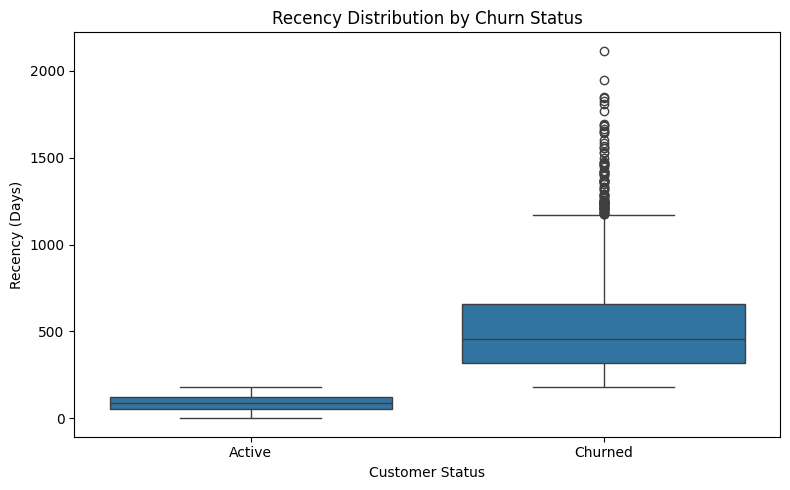

In [28]:
# =========================================================
# CELL 29 — RECENCY BY CHURN
# =========================================================

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=rfm,
    x="Churn_Label",
    y="Recency_Days"
)

plt.title("Recency Distribution by Churn Status")
plt.xlabel("Customer Status")
plt.ylabel("Recency (Days)")

plt.tight_layout()
plt.show()

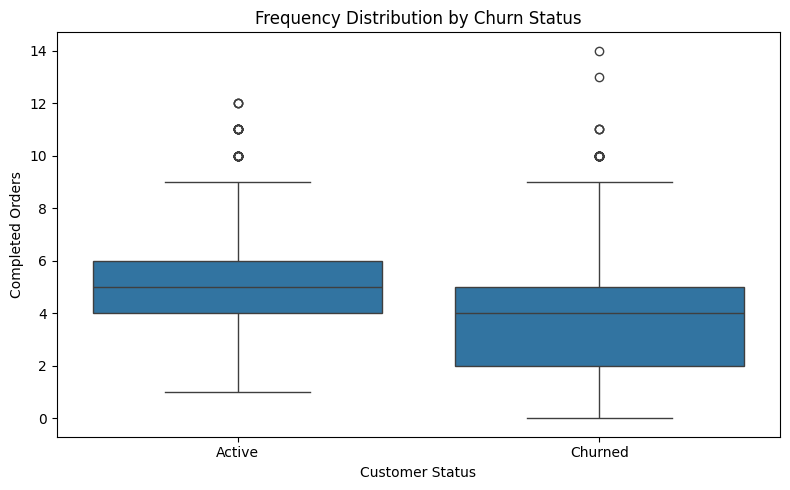

In [29]:
# =========================================================
# CELL 30 — FREQUENCY BY CHURN
# =========================================================

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=rfm,
    x="Churn_Label",
    y="Frequency"
)

plt.title("Frequency Distribution by Churn Status")
plt.xlabel("Customer Status")
plt.ylabel("Completed Orders")

plt.tight_layout()
plt.show()

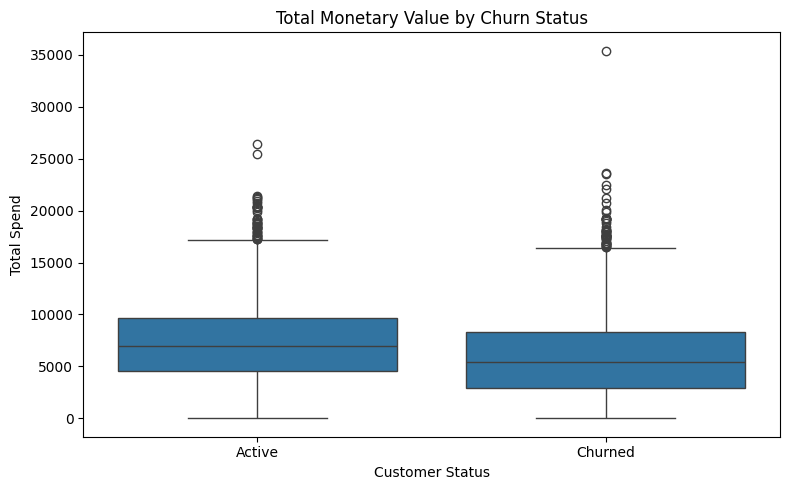

In [30]:

# =========================================================
# CELL 31 — MONETARY VALUE BY CHURN
# =========================================================

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=rfm,
    x="Churn_Label",
    y="Monetary_Total"
)

plt.title("Total Monetary Value by Churn Status")
plt.xlabel("Customer Status")
plt.ylabel("Total Spend")

plt.tight_layout()
plt.show()

In [31]:

# ============================================================
# 32. SUPPORT-TICKET FEATURE ENGINEERING
# ============================================================

print("=" * 70)
print("SUPPORT-TICKET ANALYSIS")
print("=" * 70)

print("\nAvailable support-ticket columns:")
print(support_tickets.columns.tolist())


# ------------------------------------------------------------
# Identify satisfaction column
# ------------------------------------------------------------

satisfaction_candidates = [
    "satisfaction_score",
    "satisfaction",
    "Satisfaction_Score",
    "Satisfaction"
]

satisfaction_column = next(
    (
        col
        for col in satisfaction_candidates
        if col in support_tickets.columns
    ),
    None
)


# ------------------------------------------------------------
# Identify resolution-time column
# ------------------------------------------------------------

resolution_candidates = [
    "resolution_time",
    "resolution_time_hours",
    "resolution_hours",
    "Resolution_Time",
    "Resolution_Time_Hours"
]

resolution_column = next(
    (
        col
        for col in resolution_candidates
        if col in support_tickets.columns
    ),
    None
)


print("\nDetected satisfaction column:")
print(satisfaction_column)

print("\nDetected resolution-time column:")
print(resolution_column)


# ------------------------------------------------------------
# Aggregate support tickets by customer
# ------------------------------------------------------------

support_features = (
    support_tickets
    .groupby("customer_id")
    .agg(
        Support_Ticket_Count=("customer_id", "size")
    )
    .reset_index()
)


# ------------------------------------------------------------
# Add satisfaction
# ------------------------------------------------------------

if satisfaction_column is not None:

    satisfaction_summary = (
        support_tickets
        .groupby("customer_id")[satisfaction_column]
        .mean()
        .reset_index()
        .rename(
            columns={
                satisfaction_column:
                "Average_Satisfaction"
            }
        )
    )

    support_features = support_features.merge(
        satisfaction_summary,
        on="customer_id",
        how="left"
    )

else:

    support_features["Average_Satisfaction"] = np.nan


# ------------------------------------------------------------
# Add resolution time
# ------------------------------------------------------------

if resolution_column is not None:

    resolution_summary = (
        support_tickets
        .groupby("customer_id")[resolution_column]
        .mean()
        .reset_index()
        .rename(
            columns={
                resolution_column:
                "Average_Resolution_Time"
            }
        )
    )

    support_features = support_features.merge(
        resolution_summary,
        on="customer_id",
        how="left"
    )

else:

    support_features["Average_Resolution_Time"] = np.nan


print("\nSupport features:")
display(support_features.head())


SUPPORT-TICKET ANALYSIS

Available support-ticket columns:
['ticket_id', 'customer_id', 'ticket_date', 'issue_category', 'channel', 'resolution_time_hours', 'satisfaction_score', 'ticket_text']

Detected satisfaction column:
satisfaction_score

Detected resolution-time column:
resolution_time_hours

Support features:


,customer_id,Support_Ticket_Count,Average_Satisfaction,Average_Resolution_Time
0,CUST000001,1,5.0,5.1
1,CUST000002,1,4.0,2.9
2,CUST000003,1,4.0,17.5
3,CUST000004,1,4.0,7.0
4,CUST000006,1,4.0,33.9


In [32]:
# ============================================================
# 33. MERGE SUPPORT FEATURES INTO CUSTOMER DATA
# ============================================================

customers = customers.merge(
    support_features,
    on="customer_id",
    how="left",
    suffixes=('_original', '')
)

# Customers with no support tickets are assigned zero tickets.
customers["Support_Ticket_Count"] = (
    customers["Support_Ticket_Count"]
    .fillna(0)
)

print("Support features merged successfully.")

display(
    customers[
        [
            "customer_id",
            "Support_Ticket_Count",
            "Average_Satisfaction",
            "Average_Resolution_Time",
            "Churn_Label"
        ]
    ].head(10)
)

Support features merged successfully.


,customer_id,Support_Ticket_Count,Average_Satisfaction,Average_Resolution_Time,Churn_Label
0,CUST002565,2.0,4.0,422.25,Active
1,CUST004275,1.0,3.0,10.70,Churned
2,CUST003045,1.0,5.0,20.00,Churned
3,CUST005168,1.0,3.0,11.40,Churned
4,CUST003986,1.0,4.0,34.70,Churned
5,CUST004228,0.0,NaN,NaN,Active
6,CUST002495,2.0,3.0,43.35,Churned
7,CUST004379,0.0,NaN,NaN,Churned
8,CUST004964,1.0,5.0,45.50,Churned
9,CUST004930,1.0,4.0,57.50,Active


In [33]:

# ============================================================
# 34. SUPPORT ACTIVITY VS CHURN
# ============================================================

support_churn = (
    customers
    .groupby("Churn_Label")
    .agg(
        Customers=("customer_id", "nunique"),
        Average_Tickets=("Support_Ticket_Count", "mean"),
        Average_Satisfaction=("Average_Satisfaction", "mean"),
        Average_Resolution_Time=("Average_Resolution_Time", "mean")
    )
    .reset_index()
)

support_churn["Customer_Status"] = (
    support_churn["Churn_Label"]
    .map({
        "Active": "Not Churned",
        "Churned": "Churned"
    })
)

display(
    support_churn[
        [
            "Customer_Status",
            "Customers",
            "Average_Tickets",
            "Average_Satisfaction",
            "Average_Resolution_Time"
        ]
    ]
)


,Customer_Status,Customers,Average_Tickets,Average_Satisfaction,Average_Resolution_Time
0,Not Churned,2018,0.825074,3.915331,17.320079
1,Churned,4072,0.868124,3.869762,18.794113


In [34]:

# ============================================================
# 35. RFM VS CHURN
# ============================================================

rfm_churn = (
    rfm
    .groupby("Churn_Label")
    .agg(
        Customers=("customer_id", "nunique"),
        Average_Recency=("Recency_Days", "mean"),
        Average_Frequency=("Frequency", "mean"),
        Average_Monetary=("Monetary_Total", "mean"),
        Average_Order_Value=("Monetary_Average", "mean")
    )
    .reset_index()
)

rfm_churn["Customer_Status"] = (
    rfm_churn["Churn_Label"]
    .map({
        "Active": "Not Churned",
        "Churned": "Churned"
    })
)

display(
    rfm_churn[
        [
            "Customer_Status",
            "Customers",
            "Average_Recency",
            "Average_Frequency",
            "Average_Monetary",
            "Average_Order_Value"
        ]
    ]
)


,Customer_Status,Customers,Average_Recency,Average_Frequency,Average_Monetary,Average_Order_Value
0,Not Churned,2018,89.194252,4.794351,7424.506209,1540.774487
1,Churned,4072,515.707862,3.782662,5796.941616,1366.857043


In [35]:

# ============================================================
# 36. CORRELATION ANALYSIS
# ============================================================

correlation_columns = [
    "Recency_Days",
    "Frequency",
    "Monetary_Total",
    "Monetary_Average",
    "Support_Ticket_Count",
    "Average_Satisfaction",
    "Average_Resolution_Time",
    "Churn"
]

# Create a base DataFrame for correlation by copying the relevant parts of 'customers'
# This ensures we have the customer_id, Recency_Days, Support features, and Churn
correlation_data = customers[[
    "customer_id",
    "Recency_Days",
    "Support_Ticket_Count",
    "Average_Satisfaction",
    "Average_Resolution_Time",
    "Churn"
]].copy()

# Merge RFM features (Frequency, Monetary_Total, Monetary_Average) from the 'rfm' DataFrame
# We only need these three specific columns from 'rfm' as other overlapping columns are already in 'correlation_data'
correlation_data = correlation_data.merge(
    rfm[[
        "customer_id",
        "Frequency",
        "Monetary_Total",
        "Monetary_Average"
    ]],
    on="customer_id",
    how="left"
)

correlation_matrix = correlation_data[
    correlation_columns
].corr(
    numeric_only=True
)

print("Correlation with Churn:")

display(
    correlation_matrix[
        ["Churn"]
    ].sort_values(
        "Churn",
        ascending=False
    )
)


Correlation with Churn:


,Churn
Churn,1.000000
Recency_Days,0.687658
Average_Resolution_Time,0.031938
Support_Ticket_Count,0.022083
Average_Satisfaction,-0.020167
Monetary_Average,-0.112535
Monetary_Total,-0.187458
Frequency,-0.222066


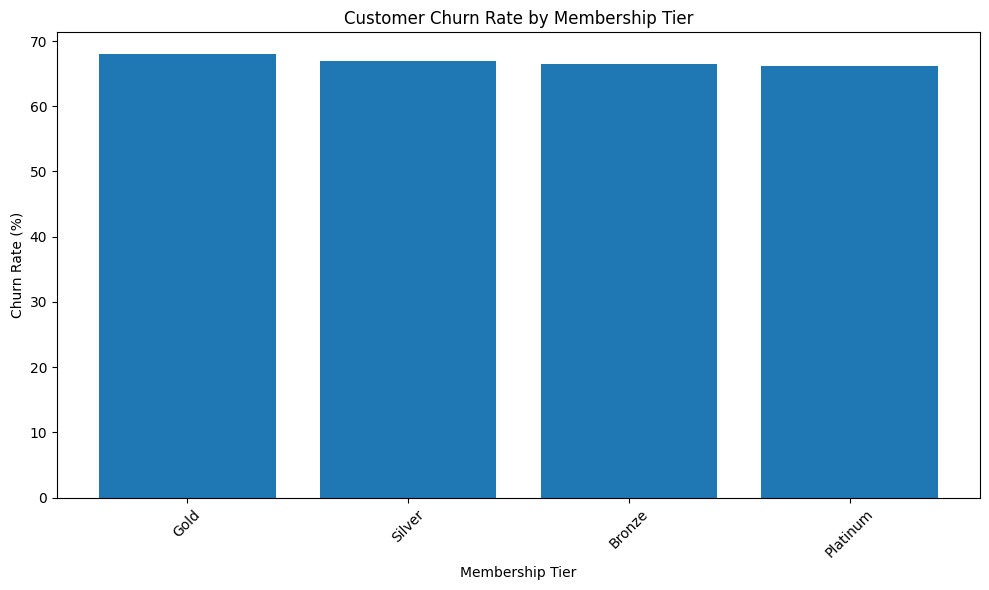

In [36]:
# ============================================================
# 37. VISUALIZATION — CHURN BY MEMBERSHIP TIER
# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    churn_by_tier.index,
    churn_by_tier.values
)

plt.title("Customer Churn Rate by Membership Tier")
plt.xlabel("Membership Tier")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

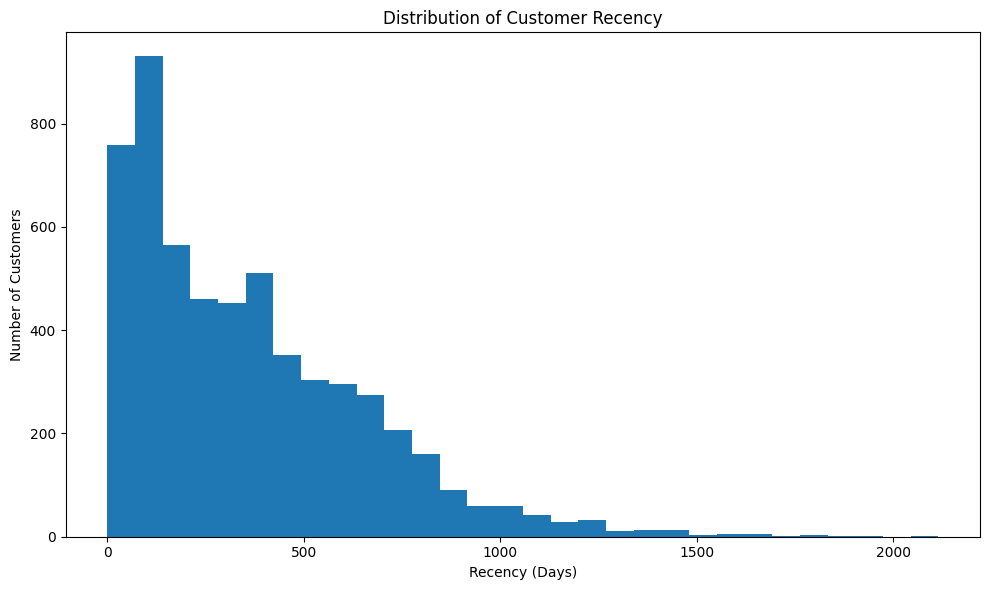

In [37]:

# ============================================================
# 38. RFM DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

plt.hist(
    rfm["Recency_Days"],
    bins=30
)

plt.title("Distribution of Customer Recency")
plt.xlabel("Recency (Days)")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()


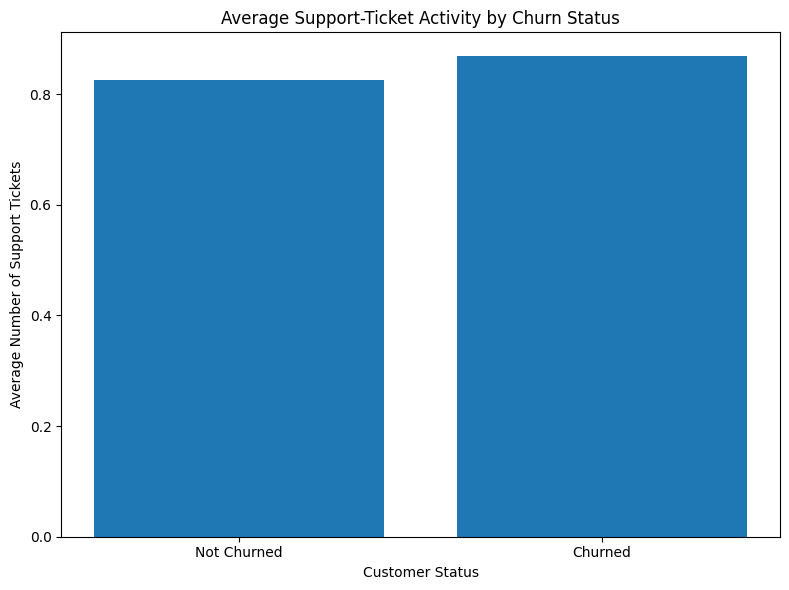

In [38]:

# ============================================================
# 39. SUPPORT TICKETS VS CHURN
# ============================================================

support_plot = (
    customers
    .groupby("Churn_Label")["Support_Ticket_Count"]
    .mean()
)

plt.figure(figsize=(8, 6))

plt.bar(
    ["Not Churned", "Churned"],
    support_plot.values
)

plt.title("Average Support-Ticket Activity by Churn Status")
plt.xlabel("Customer Status")
plt.ylabel("Average Number of Support Tickets")
plt.tight_layout()
plt.show()


In [39]:

# ============================================================
# 40. KEY FINDING SUPPORT
# ============================================================

print("=" * 70)
print("KEY BUSINESS FINDING SUPPORT")
print("=" * 70)


# Overall churn
print(
    f"\n1. Overall churn rate: "
    f"{overall_churn:.2f}%"
)


# Highest tier churn
highest_tier_name = churn_by_tier.idxmax()
highest_tier_churn_rate = churn_by_tier.max()

print(
    f"\n2. Highest-churn membership tier: "
    f"{highest_tier_name} "
    f"({highest_tier_churn_rate:.2f}%)"
)


# Highest channel churn
highest_channel_name = churn_by_channel.idxmax()
highest_channel_churn_rate = churn_by_channel.max()

print(
    f"\n3. Highest-churn preferred channel: "
    f"{highest_channel_name} "
    f"({highest_channel_churn_rate:.2f}%)"
)


# Highest referral churn
highest_referral = churn_by_referral.loc[
    churn_by_referral["Churn_Rate"].idxmax()
]
highest_referral_source_name = highest_referral.name
highest_referral_churn_rate = highest_referral['Churn_Rate']

print(
    f"\n4. Highest-churn referral source: "
    f"{highest_referral_source_name} "
    f"({highest_referral_churn_rate:.2f}%)"
)


# RFM comparison
print("\n5. RFM comparison:")

display(
    rfm_churn[
        [
            "Customer_Status",
            "Average_Recency",
            "Average_Frequency",
            "Average_Monetary"
        ]
    ]
)


# Support comparison
print("\n6. Support-ticket comparison:")

display(
    support_churn[
        [
            "Customer_Status",
            "Average_Tickets",
            "Average_Satisfaction",
            "Average_Resolution_Time"
        ]
    ]
)


KEY BUSINESS FINDING SUPPORT

1. Overall churn rate: 66.86%

2. Highest-churn membership tier: Gold (67.94%)

3. Highest-churn preferred channel: In-Store (67.96%)

4. Highest-churn referral source: Friend Referral (68.73%)

5. RFM comparison:


,Customer_Status,Average_Recency,Average_Frequency,Average_Monetary
0,Not Churned,89.194252,4.794351,7424.506209
1,Churned,515.707862,3.782662,5796.941616



6. Support-ticket comparison:


,Customer_Status,Average_Tickets,Average_Satisfaction,Average_Resolution_Time
0,Not Churned,0.825074,3.915331,17.320079
1,Churned,0.868124,3.869762,18.794113


In [55]:

# ============================================================
# 42. SAVE PHASE 7 SUMMARY TABLES
# ============================================================

churn_by_tier.to_csv(
    os.path.join(
        PHASE7_PATH,
        "churn_by_tier.csv"
    ),
    index=False
)

churn_by_channel.to_csv(
    os.path.join(
        PHASE7_PATH,
        "churn_by_channel.csv"
    ),
    index=False
)

state_churn.to_csv(
    os.path.join(
        PHASE7_PATH,
        "churn_by_state.csv"
    ),
    index=False
)

churn_by_referral.to_csv(
    os.path.join(
        PHASE7_PATH,
        "churn_by_referral.csv"
    ),
    index=False
)

churn_by_cohort.to_csv(
    os.path.join(
        PHASE7_PATH,
        "churn_by_signup_cohort.csv"
    ),
    index=False
)

support_churn.to_csv(
    os.path.join(
        PHASE7_PATH,
        "support_vs_churn.csv"
    ),
    index=False
)

rfm_churn.to_csv(
    os.path.join(
        PHASE7_PATH,
        "rfm_vs_churn.csv"
    ),
    index=False
)

print("Phase 7 summary tables saved successfully.")


Phase 7 summary tables saved successfully.


In [56]:
# ============================================================
# PHASE 7 — FINAL CUSTOMER-LEVEL ANALYSIS

# ============================================================

import os
import pandas as pd

# ------------------------------------------------------------
# 1. START WITH CLEAN CUSTOMER DATA
# ------------------------------------------------------------

customer_base = customers.copy()

# Remove any previously-created analysis columns
# so that we do not create _x and _y duplicates.

analysis_columns = [
    "Churn",
    "Churn_Label",
    "Recency_Days",
    "Frequency",
    "Monetary_Total",
    "Monetary_Average",
    "Support_Ticket_Count",
    "Average_Satisfaction",
    "Average_Resolution_Time",
    "Customer_Status"
]

customer_base = customer_base.drop(
    columns=[
        col for col in analysis_columns
        if col in customer_base.columns
    ],
    errors="ignore"
)

print("Customer base prepared:")
print(customer_base.shape)


# ------------------------------------------------------------
# 2. SELECT RFM + CHURN FEATURES
# ------------------------------------------------------------

rfm_features = rfm[
    [
        "customer_id",
        "Recency_Days",
        "Churn",
        "Churn_Label",
        "Frequency",
        "Monetary_Total",
        "Monetary_Average"
    ]
].copy()

print("\nRFM features:")
print(rfm_features.columns.tolist())


# ------------------------------------------------------------
# 3. SELECT SUPPORT-TICKET FEATURES
# ------------------------------------------------------------

support_features_final = support_features[
    [
        "customer_id",
        "Support_Ticket_Count",
        "Average_Satisfaction",
        "Average_Resolution_Time"
    ]
].copy()

print("\nSupport features:")
print(support_features_final.columns.tolist())


# ------------------------------------------------------------
# 4. MERGE CUSTOMER + RFM
# ------------------------------------------------------------

customer_analysis = customer_base.merge(
    rfm_features,
    on="customer_id",
    how="left"
)

print("\nAfter RFM merge:")
print(customer_analysis.shape)


# ------------------------------------------------------------
# 5. MERGE CUSTOMER + SUPPORT FEATURES
# ------------------------------------------------------------

customer_analysis = customer_analysis.merge(
    support_features_final,
    on="customer_id",
    how="left"
)

print("\nAfter support-ticket merge:")
print(customer_analysis.shape)


# ------------------------------------------------------------
# 6. CREATE CUSTOMER STATUS
# ------------------------------------------------------------
# Your actual Churn_Label values are:
# "Churned"
# "Active"

customer_analysis["Customer_Status"] = (
    customer_analysis["Churn_Label"]
    .map({
        "Churned": "Churned",
        "Active": "Not Churned"
    })
)


# ------------------------------------------------------------
# 7. DEFINE PHASE 7 OUTPUT FOLDER
# ------------------------------------------------------------

PHASE7_PATH = (
    "/content/drive/MyDrive/"
    "Meridian Retail Group - Customer Churn Capstone/"
    "Data/Phase 7 Analysis"
)

os.makedirs(PHASE7_PATH, exist_ok=True)


# ------------------------------------------------------------
# 8. SAVE FINAL CUSTOMER-LEVEL DATASET
# ------------------------------------------------------------

output_file = os.path.join(
    PHASE7_PATH,
    "customer_churn_analysis.csv"
)

customer_analysis.to_csv(
    output_file,
    index=False
)


# ============================================================
# 9. FINAL VALIDATION
# ============================================================

print("\n" + "=" * 70)
print("PHASE 7 CUSTOMER ANALYSIS — FINAL VALIDATION")
print("=" * 70)

print("\nDataset shape:")
print(customer_analysis.shape)


print("\nRequired columns:")

required_columns = [
    "customer_id",
    "Churn",
    "Churn_Label",
    "Customer_Status",
    "Recency_Days",
    "Frequency",
    "Monetary_Total",
    "Monetary_Average",
    "Support_Ticket_Count",
    "Average_Satisfaction",
    "Average_Resolution_Time"
]

for column in required_columns:
    if column in customer_analysis.columns:
        print("✓", column)
    else:
        print("✗ MISSING:", column)


print("\nChurn label distribution:")
print(
    customer_analysis["Churn_Label"]
    .value_counts(dropna=False)
)


print("\nCustomer status distribution:")
print(
    customer_analysis["Customer_Status"]
    .value_counts(dropna=False)
)


print("\nSupport-ticket columns preview:")

display(
    customer_analysis[
        [
            "customer_id",
            "Churn_Label",
            "Customer_Status",
            "Support_Ticket_Count",
            "Average_Satisfaction",
            "Average_Resolution_Time"
        ]
    ].head(10)
)


print("\nOutput file:")
print(output_file)

print("\nFile exists:")
print(os.path.exists(output_file))

Customer base prepared:
(6090, 26)

RFM features:
['customer_id', 'Recency_Days', 'Churn', 'Churn_Label', 'Frequency', 'Monetary_Total', 'Monetary_Average']

Support features:
['customer_id', 'Support_Ticket_Count', 'Average_Satisfaction', 'Average_Resolution_Time']

After RFM merge:
(6090, 32)

After support-ticket merge:
(6090, 35)

PHASE 7 CUSTOMER ANALYSIS — FINAL VALIDATION

Dataset shape:
(6090, 36)

Required columns:
✓ customer_id
✓ Churn
✓ Churn_Label
✓ Customer_Status
✓ Recency_Days
✓ Frequency
✓ Monetary_Total
✓ Monetary_Average
✓ Support_Ticket_Count
✓ Average_Satisfaction
✓ Average_Resolution_Time

Churn label distribution:
Churn_Label
Churned    4072
Active     2018
Name: count, dtype: int64

Customer status distribution:
Customer_Status
Churned        4072
Not Churned    2018
Name: count, dtype: int64

Support-ticket columns preview:


,customer_id,Churn_Label,Customer_Status,Support_Ticket_Count,Average_Satisfaction,Average_Resolution_Time
0,CUST002565,Active,Not Churned,2.0,4.0,422.25
1,CUST004275,Churned,Churned,1.0,3.0,10.70
2,CUST003045,Churned,Churned,1.0,5.0,20.00
3,CUST005168,Churned,Churned,1.0,3.0,11.40
4,CUST003986,Churned,Churned,1.0,4.0,34.70
5,CUST004228,Active,Not Churned,NaN,NaN,NaN
6,CUST002495,Churned,Churned,2.0,3.0,43.35
7,CUST004379,Churned,Churned,NaN,NaN,NaN
8,CUST004964,Churned,Churned,1.0,5.0,45.50
9,CUST004930,Active,Not Churned,1.0,4.0,57.50



Output file:
/content/drive/MyDrive/Meridian Retail Group - Customer Churn Capstone/Data/Phase 7 Analysis/customer_churn_analysis.csv

File exists:
True


In [42]:
# ============================================================
# 43. FINAL PHASE 7 VALIDATION
# ============================================================

print("=" * 70)
print("PHASE 7 FINAL VALIDATION")
print("=" * 70)

print("\nCustomer analysis shape:")
print(customers.shape)

print("\nRequired RFM columns:")
rfm_columns = [
    "Recency_Days",
    "Frequency",
    "Monetary_Total",
    "Monetary_Average"
]

for col in rfm_columns:
    print(
        f"✓ {col}:",
        col in customers.columns
    )

print("\nRequired support columns:")

support_columns = [
    "Support_Ticket_Count",
    "Average_Satisfaction",
    "Average_Resolution_Time"
]

for col in support_columns:
    print(
        f"✓ {col}:",
        col in customers.columns
    )

print("\nChurn column:")
print(
    "✓ Churn_Label:",
    "Churn_Label" in customers.columns
)

print("\nPhase 7 output files:")

for file in sorted(os.listdir(PHASE7_PATH)):
    print("✓", file)

print("\n" + "=" * 70)
print("PHASE 7 COMPLETED SUCCESSFULLY")
print("=" * 70)


PHASE 7 FINAL VALIDATION

Customer analysis shape:
(6090, 32)

Required RFM columns:
✓ Recency_Days: True
✓ Frequency: False
✓ Monetary_Total: False
✓ Monetary_Average: False

Required support columns:
✓ Support_Ticket_Count: True
✓ Average_Satisfaction: True
✓ Average_Resolution_Time: True

Churn column:
✓ Churn_Label: True

Phase 7 output files:
✓ churn_by_channel.csv
✓ churn_by_referral.csv
✓ churn_by_signup_cohort.csv
✓ churn_by_state.csv
✓ churn_by_tier.csv
✓ customer_churn_analysis.csv
✓ rfm_vs_churn.csv
✓ support_vs_churn.csv

PHASE 7 COMPLETED SUCCESSFULLY
